# 01 Main EDA

Executable EDA source of truth for the clean research line. This notebook reads `data/train.csv`, `data/test.csv`, and `data/gender_submission.csv`.

Boundaries: no model training, no final model decisions, no row-level correctness checks on `test.csv`. `gender_submission.csv` is shown only as a baseline prediction file, not truth.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display

PROJECT_ROOT = Path.cwd()
if not (PROJECT_ROOT / "data" / "train.csv").exists():
    PROJECT_ROOT = PROJECT_ROOT.parent

DATA_DIR = PROJECT_ROOT / "data"
train = pd.read_csv(DATA_DIR / "train.csv")
test = pd.read_csv(DATA_DIR / "test.csv")
gender_submission = pd.read_csv(DATA_DIR / "gender_submission.csv")

pd.set_option("display.max_columns", 80)
pd.set_option("display.width", 160)
plt.style.use("ggplot")

## Dataset Shape

Basic file sizes and roles. This is descriptive EDA only.

In [2]:
shape_table = pd.DataFrame(
    [
        {"file": "train.csv", "rows": train.shape[0], "columns": train.shape[1], "role": "train-side EDA / CV / OOF / holdout"},
        {"file": "test.csv", "rows": test.shape[0], "columns": test.shape[1], "role": "distribution / alignment / final prediction input"},
        {"file": "gender_submission.csv", "rows": gender_submission.shape[0], "columns": gender_submission.shape[1], "role": "baseline prediction file, not truth"},
    ]
)
display(shape_table)

,file,rows,columns,role
0,train.csv,891,12,train-side EDA / CV / OOF / holdout
1,test.csv,418,11,distribution / alignment / final prediction input
2,gender_submission.csv,418,2,"baseline prediction file, not truth"


## Column Presence

Check schema differences between `train.csv` and `test.csv`.

In [3]:
train_only = [column for column in train.columns if column not in test.columns]
test_only = [column for column in test.columns if column not in train.columns]

display(pd.DataFrame({"columns_only_in_train": train_only or ["none"]}))
display(pd.DataFrame({"columns_only_in_test": test_only or ["none"]}))

,columns_only_in_train
0,Survived


,columns_only_in_test
0,none


## Target Availability

`Survived` exists only in `train.csv`. All target-based checks below use `train.csv` only. `gender_submission.csv` is a baseline prediction file, not truth.

In [4]:
target_availability = pd.DataFrame(
    [
        {
            "file": "train.csv",
            "has_target_labels": "Survived" in train.columns,
            "has_column_named_Survived": "Survived" in train.columns,
            "role": "training labels",
        },
        {
            "file": "test.csv",
            "has_target_labels": False,
            "has_column_named_Survived": "Survived" in test.columns,
            "role": "no labels",
        },
        {
            "file": "gender_submission.csv",
            "has_target_labels": False,
            "has_column_named_Survived": "Survived" in gender_submission.columns,
            "role": "baseline prediction file, not truth",
        },
    ]
)
display(target_availability)
display(gender_submission.head())

,file,has_target_labels,has_column_named_Survived,role
0,train.csv,True,True,training labels
1,test.csv,False,False,no labels
2,gender_submission.csv,False,True,"baseline prediction file, not truth"


,PassengerId,Survived
0,892,0
1,893,1
2,894,0
3,895,0
4,896,1


## Train/Test Roles

`test.csv` must not be used for row-level correctness because it has no `Survived`. It can be used for distribution and schema alignment checks.

In [5]:
role_table = pd.DataFrame(
    [
        {"data": "train.csv", "allowed": "train-side EDA, CV, OOF, holdout", "not_allowed": "none inside train-only protocol"},
        {"data": "test.csv", "allowed": "distribution, missingness, schema alignment, final prediction input", "not_allowed": "row-level correctness / local test accuracy"},
        {"data": "gender_submission.csv", "allowed": "baseline prediction reference", "not_allowed": "truth labels / local correctness"},
    ]
)
display(role_table)

,data,allowed,not_allowed
0,train.csv,"train-side EDA, CV, OOF, holdout",none inside train-only protocol
1,test.csv,"distribution, missingness, schema alignment, f...",row-level correctness / local test accuracy
2,gender_submission.csv,baseline prediction reference,truth labels / local correctness


## Target Distribution In Train

This is a train-only outcome layer for basic EDA. It uses `Survived` only in `train.csv` and does not define deployable rules or validation decisions.

In [6]:
target_distribution = (
    train["Survived"]
    .value_counts(dropna=False)
    .rename_axis("Survived")
    .reset_index(name="rows")
    .sort_values("Survived")
)
target_distribution["rate"] = (target_distribution["rows"] / len(train)).round(4)
display(target_distribution)

,Survived,rows,rate
0,0,549,0.6162
1,1,342,0.3838


## Survival By Core Raw Groups

These summaries are target-based train-only EDA. They describe observed `train.csv` outcomes and must not be used as direct test-side correctness logic.

In [7]:
def survival_summary(frame, group_cols):
    summary = (
        frame.groupby(group_cols, dropna=False)["Survived"]
        .agg(rows="count", survived="sum", survival_rate="mean")
        .reset_index()
        .sort_values(group_cols)
    )
    summary["died"] = summary["rows"] - summary["survived"]
    summary["survival_rate"] = summary["survival_rate"].round(4)
    return summary[[*group_cols, "rows", "survived", "died", "survival_rate"]]

display(survival_summary(train, ["Sex"]))
display(survival_summary(train, ["Pclass"]))
display(survival_summary(train, ["Embarked"]))
display(survival_summary(train, ["Sex", "Pclass"]))

,Sex,rows,survived,died,survival_rate
0,female,314,233,81,0.7420
1,male,577,109,468,0.1889


,Pclass,rows,survived,died,survival_rate
0,1,216,136,80,0.6296
1,2,184,87,97,0.4728
2,3,491,119,372,0.2424


,Embarked,rows,survived,died,survival_rate
0,C,168,93,75,0.5536
1,Q,77,30,47,0.3896
2,S,644,217,427,0.3370
3,NaN,2,2,0,1.0000


,Sex,Pclass,rows,survived,died,survival_rate
0,female,1,94,91,3,0.9681
1,female,2,76,70,6,0.9211
2,female,3,144,72,72,0.5000
3,male,1,122,45,77,0.3689
4,male,2,108,17,91,0.1574
5,male,3,347,47,300,0.1354


## Survival By SibSp and Parch

Train-only. Both are in `raw_tabular` but their survival signal is not shown in the core groups block above.

,SibSp,rows,survived,died,survival_rate
0,0,608,210,398,0.3454
1,1,209,112,97,0.5359
2,2,28,13,15,0.4643
3,3,16,4,12,0.2500
4,4,18,3,15,0.1667
5,5,5,0,5,0.0000
6,8,7,0,7,0.0000


,Parch,rows,survived,died,survival_rate
0,0,678,233,445,0.3437
1,1,118,65,53,0.5508
2,2,80,40,40,0.5000
3,3,5,3,2,0.6000
4,4,4,0,4,0.0000
5,5,5,1,4,0.2000
6,6,1,0,1,0.0000


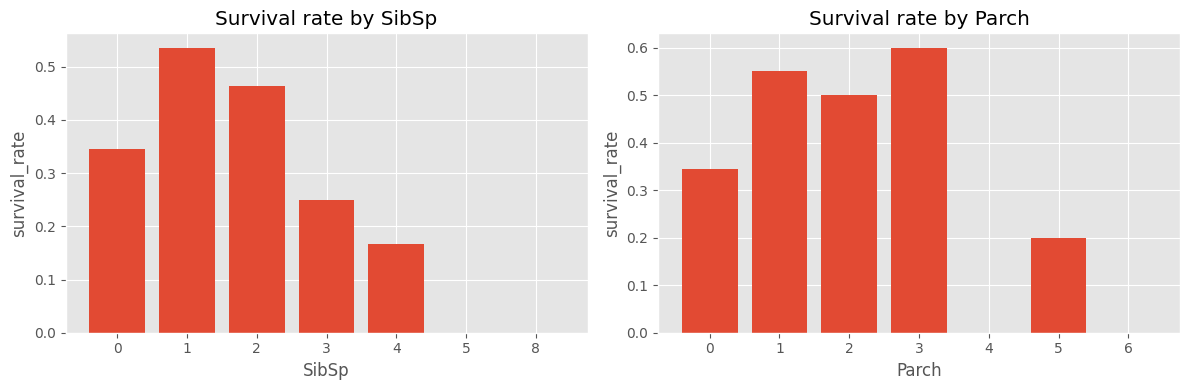

In [8]:
display(survival_summary(train, ["SibSp"]))
display(survival_summary(train, ["Parch"]))

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ax, col in zip(axes, ["SibSp", "Parch"]):
    _grp = train.groupby(col, dropna=False)["Survived"].mean().reset_index()
    ax.bar(_grp[col].astype(str), _grp["Survived"])
    ax.set_title(f"Survival rate by {col}")
    ax.set_xlabel(col)
    ax.set_ylabel("survival_rate")
plt.tight_layout()
plt.show()

## Survival By Age

Train-only. Missing-age rows shown separately before bucketing. Buckets: child (<12), teen (13-18), young adult (19-35), middle (36-60), senior (61+).

,AgeMissing,rows,survived,died,survival_rate
0,False,714,290,424,0.4062
1,True,177,52,125,0.2938


,AgeBucket,rows,survived,died,survival_rate
0,0-12,69,40,29,0.5797
1,13-18,70,30,40,0.4286
2,19-35,358,137,221,0.3827
3,36-60,195,78,117,0.4000
4,61+,22,5,17,0.2273


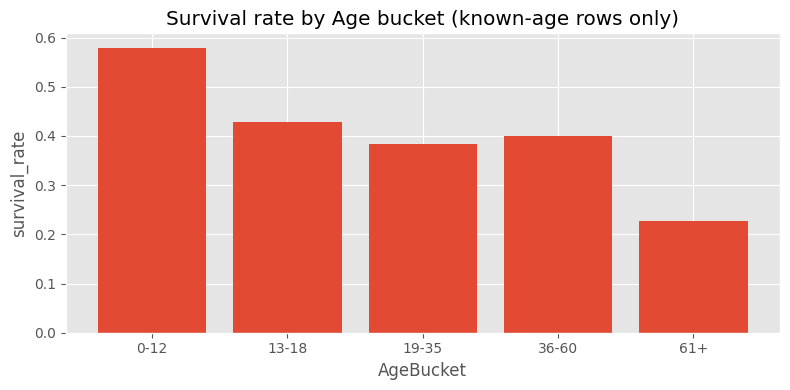

In [9]:
_age_bins   = [0, 12, 18, 35, 60, 120]
_age_labels = ["0-12", "13-18", "19-35", "36-60", "61+"]
_age_bucket = pd.cut(train["Age"], bins=_age_bins, labels=_age_labels)

display(survival_summary(train.assign(AgeMissing=train["Age"].isna()), ["AgeMissing"]))
display(survival_summary(
    train.assign(AgeBucket=_age_bucket).dropna(subset=["Age"]), ["AgeBucket"]
))

fig, ax = plt.subplots(figsize=(8, 4))
_grp = (
    train.assign(AgeBucket=_age_bucket)
    .dropna(subset=["Age"])
    .groupby("AgeBucket", observed=True)["Survived"].mean()
)
ax.bar(_grp.index.astype(str), _grp.values)
ax.set_title("Survival rate by Age bucket (known-age rows only)")
ax.set_xlabel("AgeBucket")
ax.set_ylabel("survival_rate")
plt.tight_layout()
plt.show()

## Missing Values

`Survived` is absent from `test.csv` by design. That absence is not a missing value problem.

In [10]:
all_columns = list(train.columns) + [column for column in test.columns if column not in train.columns]
missing_rows = []

for column in all_columns:
    in_train = column in train.columns
    in_test = column in test.columns
    if column == "Survived" and in_train and not in_test:
        role = "target_only_in_train"
    elif in_train and in_test:
        role = "shared"
    elif in_train:
        role = "train_only"
    else:
        role = "test_only"

    missing_rows.append(
        {
            "column": column,
            "role": role,
            "train_missing": int(train[column].isna().sum()) if in_train else "not_in_train",
            "train_missing_pct": round(float(train[column].isna().mean() * 100), 4) if in_train else "not_in_train",
            "test_missing": int(test[column].isna().sum()) if in_test else "not_in_test",
            "test_missing_pct": round(float(test[column].isna().mean() * 100), 4) if in_test else "not_in_test",
        }
    )

missing_table = pd.DataFrame(missing_rows)
display(missing_table)

,column,role,train_missing,train_missing_pct,test_missing,test_missing_pct
0,PassengerId,shared,0,0.0000,0,0.0
1,Survived,target_only_in_train,0,0.0000,not_in_test,not_in_test
2,Pclass,shared,0,0.0000,0,0.0
3,Name,shared,0,0.0000,0,0.0
4,Sex,shared,0,0.0000,0,0.0
5,Age,shared,177,19.8653,86,20.5742
6,SibSp,shared,0,0.0000,0,0.0
7,Parch,shared,0,0.0000,0,0.0
8,Ticket,shared,0,0.0000,0,0.0
9,Fare,shared,0,0.0000,1,0.2392


## Fare = 0 Audit

`Fare == 0` rows are a structural anomaly (possible crew or booking errors). Shown for completeness; no imputation decision is made in this notebook.

In [11]:
_fare_zero_train = train[train["Fare"] == 0]
_fare_zero_test  = test[test["Fare"] == 0]

display(pd.DataFrame([
    {"dataset": "train", "fare_zero_count": len(_fare_zero_train),
     "fare_zero_pct": round(len(_fare_zero_train) / len(train) * 100, 4)},
    {"dataset": "test",  "fare_zero_count": len(_fare_zero_test),
     "fare_zero_pct": round(len(_fare_zero_test)  / len(test)  * 100, 4)},
]))

display(_fare_zero_train[[
    "PassengerId", "Pclass", "Sex", "Age", "SibSp", "Parch",
    "Ticket", "Embarked", "Survived"
]])

,dataset,fare_zero_count,fare_zero_pct
0,train,15,1.6835
1,test,2,0.4785


,PassengerId,Pclass,Sex,Age,SibSp,Parch,Ticket,Embarked,Survived
179,180,3,male,36.0,0,0,LINE,S,0
263,264,1,male,40.0,0,0,112059,S,0
271,272,3,male,25.0,0,0,LINE,S,1
277,278,2,male,NaN,0,0,239853,S,0
302,303,3,male,19.0,0,0,LINE,S,0
413,414,2,male,NaN,0,0,239853,S,0
466,467,2,male,NaN,0,0,239853,S,0
481,482,2,male,NaN,0,0,239854,S,0
597,598,3,male,49.0,0,0,LINE,S,0
633,634,1,male,NaN,0,0,112052,S,0


## Basic Distributions For Main Raw Columns

Raw-column distributions support EDA and alignment checks. Target-based distribution checks in this notebook are train-only.

,count,mean,std,min,1%,25%,50%,75%,99%,max
Age,714.0,29.699118,14.526497,0.42,1.0,20.1250,28.0000,38.0,65.87000,80.0000
Fare,891.0,32.204208,49.693429,0.00,0.0,7.9104,14.4542,31.0,249.00622,512.3292
SibSp,891.0,0.523008,1.102743,0.00,0.0,0.0000,0.0000,1.0,5.00000,8.0000
Parch,891.0,0.381594,0.806057,0.00,0.0,0.0000,0.0000,0.0,4.00000,6.0000


,train_count,test_count
Pclass,,
3,491,218
1,216,107
2,184,93


,train_count,test_count
Sex,,
male,577,266
female,314,152


,train_count,test_count
Embarked,,
S,644,270
C,168,102
Q,77,46
NaN,2,0


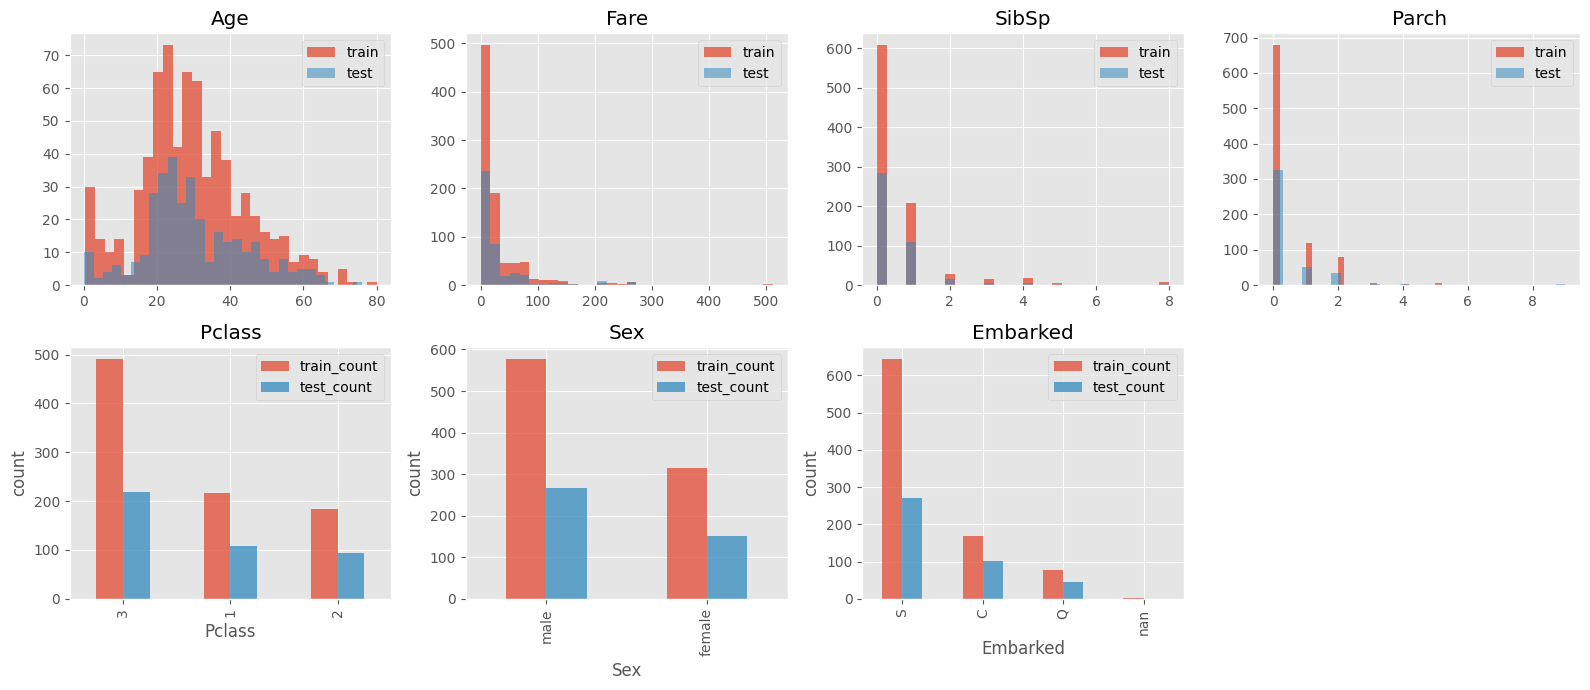

In [12]:
main_numeric = ["Age", "Fare", "SibSp", "Parch"]
main_categorical = ["Pclass", "Sex", "Embarked"]

display(train[main_numeric].describe(percentiles=[0.01, 0.25, 0.5, 0.75, 0.99]).T)

for column in main_categorical:
    counts = pd.concat(
        [
            train[column].value_counts(dropna=False).rename("train_count"),
            test[column].value_counts(dropna=False).rename("test_count"),
        ],
        axis=1,
    ).fillna(0).astype(int)
    display(counts)

fig, axes = plt.subplots(2, 4, figsize=(16, 7))
for ax, column in zip(axes[0], main_numeric):
    ax.hist(train[column].dropna(), bins=30, alpha=0.75, label="train")
    ax.hist(test[column].dropna(), bins=30, alpha=0.55, label="test")
    ax.set_title(column)
    ax.legend()

for ax, column in zip(axes[1], main_categorical):
    counts = pd.concat(
        [
            train[column].value_counts(dropna=False).rename("train_count"),
            test[column].value_counts(dropna=False).rename("test_count"),
        ],
        axis=1,
    ).fillna(0).astype(int)
    counts.plot(kind="bar", ax=ax, alpha=0.75)
    ax.set_title(column)
    ax.set_ylabel("count")
    ax.legend()

axes[1, 3].axis("off")
plt.tight_layout()

## Outlier Audit For Raw Numeric Features

This is a raw descriptive audit only. It does not decide to remove, clip, winsorize, or otherwise preprocess outliers.

,train_missing_pct,test_missing_pct,train_q0.0,train_q0.01,train_q0.25,train_q0.5,train_q0.75,train_q0.95,train_q0.99,train_q1.0,test_q0.0,test_q0.01,test_q0.25,test_q0.5,test_q0.75,test_q0.95,test_q0.99,test_q1.0
Age,19.8653,20.5742,0.42,1.0,20.1250,28.0000,38.0,56.0000,65.8700,80.0000,0.17,0.8579,21.0000,27.0000,39.0,57.00,64.000,76.0000
SibSp,0.0000,0.0000,0.00,0.0,0.0000,0.0000,1.0,3.0000,5.0000,8.0000,0.00,0.0000,0.0000,0.0000,1.0,2.00,4.000,8.0000
Parch,0.0000,0.0000,0.00,0.0,0.0000,0.0000,0.0,2.0000,4.0000,6.0000,0.00,0.0000,0.0000,0.0000,0.0,2.00,4.000,9.0000
Fare,0.0000,0.2392,0.00,0.0,7.9104,14.4542,31.0,112.0792,249.0062,512.3292,0.00,6.4468,7.8958,14.4542,31.5,151.55,262.375,512.3292


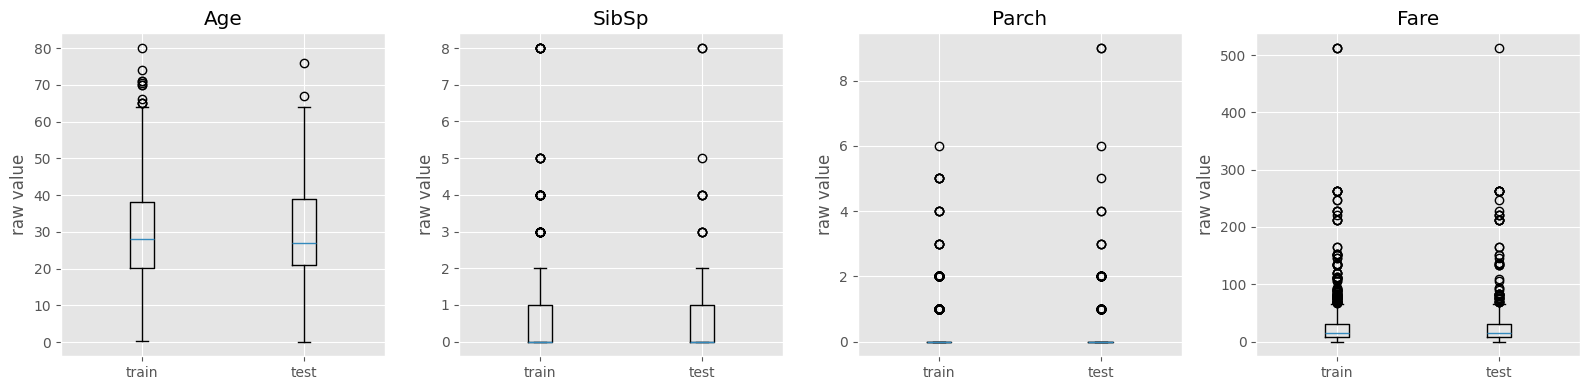

In [13]:
raw_numeric_features = ["Age", "SibSp", "Parch", "Fare"]
raw_quantile_levels = [0.00, 0.01, 0.25, 0.50, 0.75, 0.95, 0.99, 1.00]

train_raw_quantiles = train[raw_numeric_features].quantile(raw_quantile_levels).T.add_prefix("train_q")
test_raw_quantiles = test[raw_numeric_features].quantile(raw_quantile_levels).T.add_prefix("test_q")
raw_missing = pd.DataFrame(
    {
        "train_missing_pct": train[raw_numeric_features].isna().mean() * 100,
        "test_missing_pct": test[raw_numeric_features].isna().mean() * 100,
    }
)

display(pd.concat([raw_missing, train_raw_quantiles, test_raw_quantiles], axis=1).round(4))

fig, axes = plt.subplots(1, len(raw_numeric_features), figsize=(16, 4))
for ax, column in zip(axes, raw_numeric_features):
    ax.boxplot(
        [train[column].dropna(), test[column].dropna()],
        tick_labels=["train", "test"],
        showfliers=True,
    )
    ax.set_title(column)
    ax.set_ylabel("raw value")
plt.tight_layout()

## Feature Correlation Matrix

Pearson correlations between numeric raw features and `Survived`. Train-only. Highlights feature-feature overlap (e.g. Fare vs Pclass) and marginal target associations.

,Survived,Pclass,Age,SibSp,Parch,Fare
Survived,1.000,-0.338,-0.077,-0.035,0.082,0.257
Pclass,-0.338,1.000,-0.369,0.083,0.018,-0.549
Age,-0.077,-0.369,1.000,-0.308,-0.189,0.096
SibSp,-0.035,0.083,-0.308,1.000,0.415,0.160
Parch,0.082,0.018,-0.189,0.415,1.000,0.216
Fare,0.257,-0.549,0.096,0.160,0.216,1.000


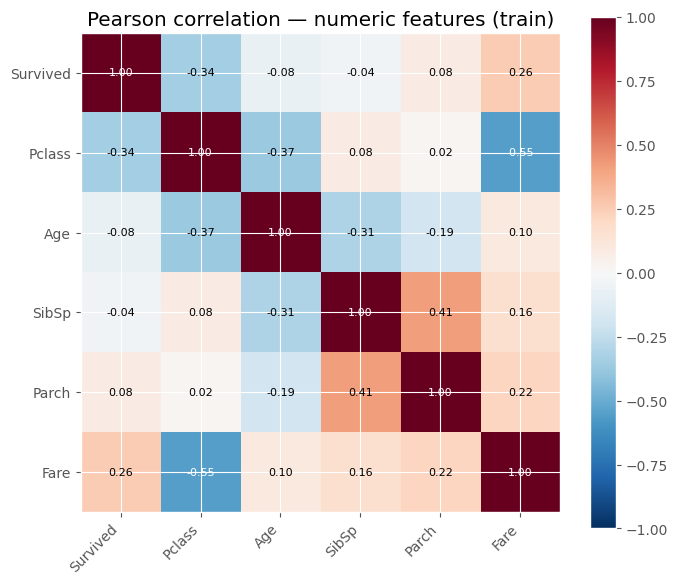

In [14]:
_corr_cols = ["Survived", "Pclass", "Age", "SibSp", "Parch", "Fare"]
_corr = train[_corr_cols].corr().round(3)
display(_corr)

fig, ax = plt.subplots(figsize=(7, 6))
_img = ax.imshow(_corr.values, cmap="RdBu_r", vmin=-1, vmax=1)
ax.set_xticks(range(len(_corr_cols)))
ax.set_yticks(range(len(_corr_cols)))
ax.set_xticklabels(_corr_cols, rotation=45, ha="right")
ax.set_yticklabels(_corr_cols)
for _i in range(len(_corr_cols)):
    for _j in range(len(_corr_cols)):
        ax.text(_j, _i, f"{_corr.values[_i, _j]:.2f}", ha="center", va="center",
                fontsize=8, color="white" if abs(_corr.values[_i, _j]) > 0.5 else "black")
plt.colorbar(_img, ax=ax)
ax.set_title("Pearson correlation — numeric features (train)")
plt.tight_layout()
plt.show()

## Basic Train/Test Alignment Notes

Alignment checks compare raw feature distributions only. They do not infer or evaluate `test.csv` correctness.

In [15]:
alignment_rows = []
for column in main_numeric:
    alignment_rows.append(
        {
            "column": column,
            "train_missing_pct": round(float(train[column].isna().mean() * 100), 4),
            "test_missing_pct": round(float(test[column].isna().mean() * 100), 4),
            "train_mean": round(float(train[column].mean()), 4),
            "test_mean": round(float(test[column].mean()), 4),
            "train_median": round(float(train[column].median()), 4),
            "test_median": round(float(test[column].median()), 4),
        }
    )

display(pd.DataFrame(alignment_rows))

for column in main_categorical:
    train_share = train[column].value_counts(normalize=True, dropna=False).rename("train_share")
    test_share = test[column].value_counts(normalize=True, dropna=False).rename("test_share")
    alignment = pd.concat([train_share, test_share], axis=1).fillna(0).round(4)
    display(alignment)

,column,train_missing_pct,test_missing_pct,train_mean,test_mean,train_median,test_median
0,Age,19.8653,20.5742,29.6991,30.2726,28.0000,27.0000
1,Fare,0.0000,0.2392,32.2042,35.6272,14.4542,14.4542
2,SibSp,0.0000,0.0000,0.5230,0.4474,0.0000,0.0000
3,Parch,0.0000,0.0000,0.3816,0.3923,0.0000,0.0000


,train_share,test_share
Pclass,,
3,0.5511,0.5215
1,0.2424,0.2560
2,0.2065,0.2225


,train_share,test_share
Sex,,
male,0.6476,0.6364
female,0.3524,0.3636


,train_share,test_share
Embarked,,
S,0.7228,0.6459
C,0.1886,0.2440
Q,0.0864,0.1100
NaN,0.0022,0.0000


## Train/Test Embarked Distribution Note

`Embarked C` share shifts from 18.9 % (train) to 24.4 % (test) — a +5.5 pp gap. This is largely explained by higher Pclass 1 composition at Cherbourg. Embarked should not be treated as a stable marginal signal independent of Pclass.